In [1]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, SequentialSampler, RandomSampler

from einops import rearrange
from functools import partial

import matplotlib.pyplot as plt
import logging
import copy
import numpy as np

import math
import os, json
from typing import List,Tuple,Dict

import sys

sys.path.append(os.path.abspath('../ai4flow/acdm'))

from turbpred.data_transformations import Transforms
from turbpred.model_diffusion import DiffusionModel
from turbpred.params import DataParams
from turbpred.model import PredictionModel
from turbpred.logger import Logger
from turbpred.params import DataParams, TrainingParams, LossParams, ModelParamsEncoder, ModelParamsDecoder, ModelParamsLatent
from turbpred.loss import PredictionLoss
from turbpred.loss_history import LossHistory
from turbpred.trainer_diffusion import TrainerDiffusion, TesterDiffusion
from functools import partial
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
# import seaborn as sns

from turbpred.foilslice_dataset import FoilsliceDataset, Transforms


device = "cuda:0" if torch.cuda.is_available() else "cpu"

/home/chunyang/miniconda3/envs/ACDM/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
startFromCheckpoint = True
useGPU = True
gpuID = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = gpuID

p_d = DataParams(batch=32, augmentations=["normalize"], sequenceLength=[3,2], randSeqOffset=True,
            dataSize=[128,64], dimension=2, simFields=["pres"], simParams=["rey"], normalizeMode="incMixed")

# pretrainPath = "/home/chunyang/projects/autoreg-pde-diffusion/models/models_inc/128_acdm-r20_00/Model.pth"
pretrainPath = ""

p_l = LossParams()
p_me = None
p_md = ModelParamsDecoder(arch="direct-ddpm+Prev", diffSteps=20, diffSchedule="linear", diffCondIntegration="noisy", trainingNoise=0.0)
p_ml = None
if startFromCheckpoint:
    p_t = TrainingParams(epochs=3, lr=0.001)
else:
    p_t = TrainingParams(epochs=3100, lr=0.0001)

model = PredictionModel(p_d, p_t, p_l, p_me, p_md, p_ml,
                        pretrainPath="" if not startFromCheckpoint else pretrainPath,
                        useGPU=useGPU)

8
in, out 12 84


In [5]:

useGPU = True
gpuID = "0"
startFromCheckpoint = False
os.environ["CUDA_VISIBLE_DEVICES"] = gpuID

testSet = FoilsliceDataset(name="foilslice dataset",
                     dataDir="/home/chunyang/projects/ai4science/ACDM4Science/data/foil_slice_processed",
                     idx_range=[1500, 1900],
                     sequenceLength=[200, 2], rey=1)

# testSet = FoilsliceDataset(name="foilslice dataset",
#                      dataDir="/home/chunyang/projects/DDPM4SCIENCE/data/foil_slice_processed",
#                      idx_range=[0, 1500],
#                      sequenceLength=[500, 2], rey=1000)

testTransformations = Transforms()
testSet.transform = testTransformations

testSampler = SequentialSampler(testSet)
testLoader = DataLoader(testSet, sampler=testSampler, batch_size=len(testSet), drop_last=False)



Loading data from 	 /home/chunyang/projects/ai4science/ACDM4Science/data/foil_slice_processed
Loading completed. Files loaded: 	400
Loading completed. Files loaded: 	1

Dataset info detail:
	 Sequence length of each sample: 200
	 Sequence skiping samples of: 2


In [6]:
import scipy
import scipy.stats

print(scipy.stats.describe(testSet[0]["data"][:, 0, :, :].flatten()))
print(scipy.stats.describe(testSet[0]["data"][:, 1, :, :].flatten()))
print(scipy.stats.describe(testSet[0]["data"][:, 2, :, :].flatten()))
# print(scipy.stats.describe(testSet[0]["data"][:, 3, :, :].flatten()))

DescribeResult(nobs=1638400, minmax=(-6.012834, 2.056632), mean=-0.07450698, variance=1.0698595616437143, skewness=-4.332170699347255, kurtosis=21.090393459504416)
DescribeResult(nobs=1638400, minmax=(-10.450092, 9.389707), mean=-0.11583311, variance=1.0778225086273245, skewness=0.7908466544845839, kurtosis=8.945939182137264)
DescribeResult(nobs=1638400, minmax=(-7.534956, 6.6892996), mean=-0.76368743, variance=1.1278199880645678, skewness=-2.130386192359706, kurtosis=7.520671635351803)


In [7]:
print(testSet[0]["data"].shape)

torch.Size([200, 4, 128, 64])


In [8]:
# sample for dataset and model inference
model = PredictionModel.load("/home/chunyang/projects/ai4science/ACDM4Science/runs/ACDM_foilslice_10/Model_E2000.pth", useGPU=True)
model.eval()
model.to(device)

evalOptions = {"numEvals": 1,
    "sequentialEvalRuns": {"lowRey": True, "highRey": True, "varReyIn": True},
    "samplingMode": "ddpm",
    "posteriorSampling": "random",
    "initialSampling": "random",
    "conditioningIntegration": "noisy"
},

if isinstance(model.modelDecoder, DiffusionModel):
    if "samplingMode" in evalOptions:
        model.modelDecoder.inferenceSamplingMode = evalOptions["samplingMode"]
    if "posteriorSampling" in evalOptions:
        model.modelDecoder.inferencePosteriorSampling = evalOptions["posteriorSampling"]
    if "initialSampling" in evalOptions:
        model.modelDecoder.inferenceInitialSampling = evalOptions["initialSampling"]
    if "conditioningIntegration" in evalOptions:
        model.modelDecoder.inferenceConditioningIntegration = evalOptions["conditioningIntegration"]

elif isinstance(model.modelDecoder, torch.nn.ModuleList):
    for module in model.modelDecoder:
        if isinstance(module, DiffusionModel):
            if "samplingMode" in evalOptions:
                module.inferenceSamplingMode = evalOptions["samplingMode"]
            if "posteriorSampling" in evalOptions:
                module.inferencePosteriorSampling = evalOptions["posteriorSampling"]
            if "initialSampling" in evalOptions:
                module.inferenceInitialSampling = evalOptions["initialSampling"]
            if "conditioningIntegration" in evalOptions:
                module.inferenceConditioningIntegration = evalOptions["conditioningIntegration"]

with torch.no_grad():
    predSamples = []
    for s, sample in enumerate(testLoader, 0):
        data = sample["data"].to(device)
        simParameters = sample["simParameters"].to(device) if type(sample["simParameters"]) is not dict else None
        prediction, _, _ = model(data, simParameters)
        print("prediction shape before double unsqueeze: ", prediction.shape)
        prediction = prediction.unsqueeze(0).unsqueeze(0)
        print("prediction shape after double unsqueeze: ", prediction.shape)
        predSamples += [prediction.cpu().numpy()]

    predSamples = np.concatenate(predSamples, axis=2)
    print("sampling finished")


Loading model from /home/chunyang/projects/ai4science/ACDM4Science/runs/ACDM_foilslice_10/Model_E2000.pth
8
in, out 12 84
prediction shape before double unsqueeze:  torch.Size([1, 200, 4, 128, 64])
prediction shape after double unsqueeze:  torch.Size([1, 1, 1, 200, 4, 128, 64])
sampling finished


In [9]:
idx_to_vis = 0

pred = predSamples[0][0, idx_to_vis, :, :, :]
ground = testSet[idx_to_vis]["data"].cpu().numpy()

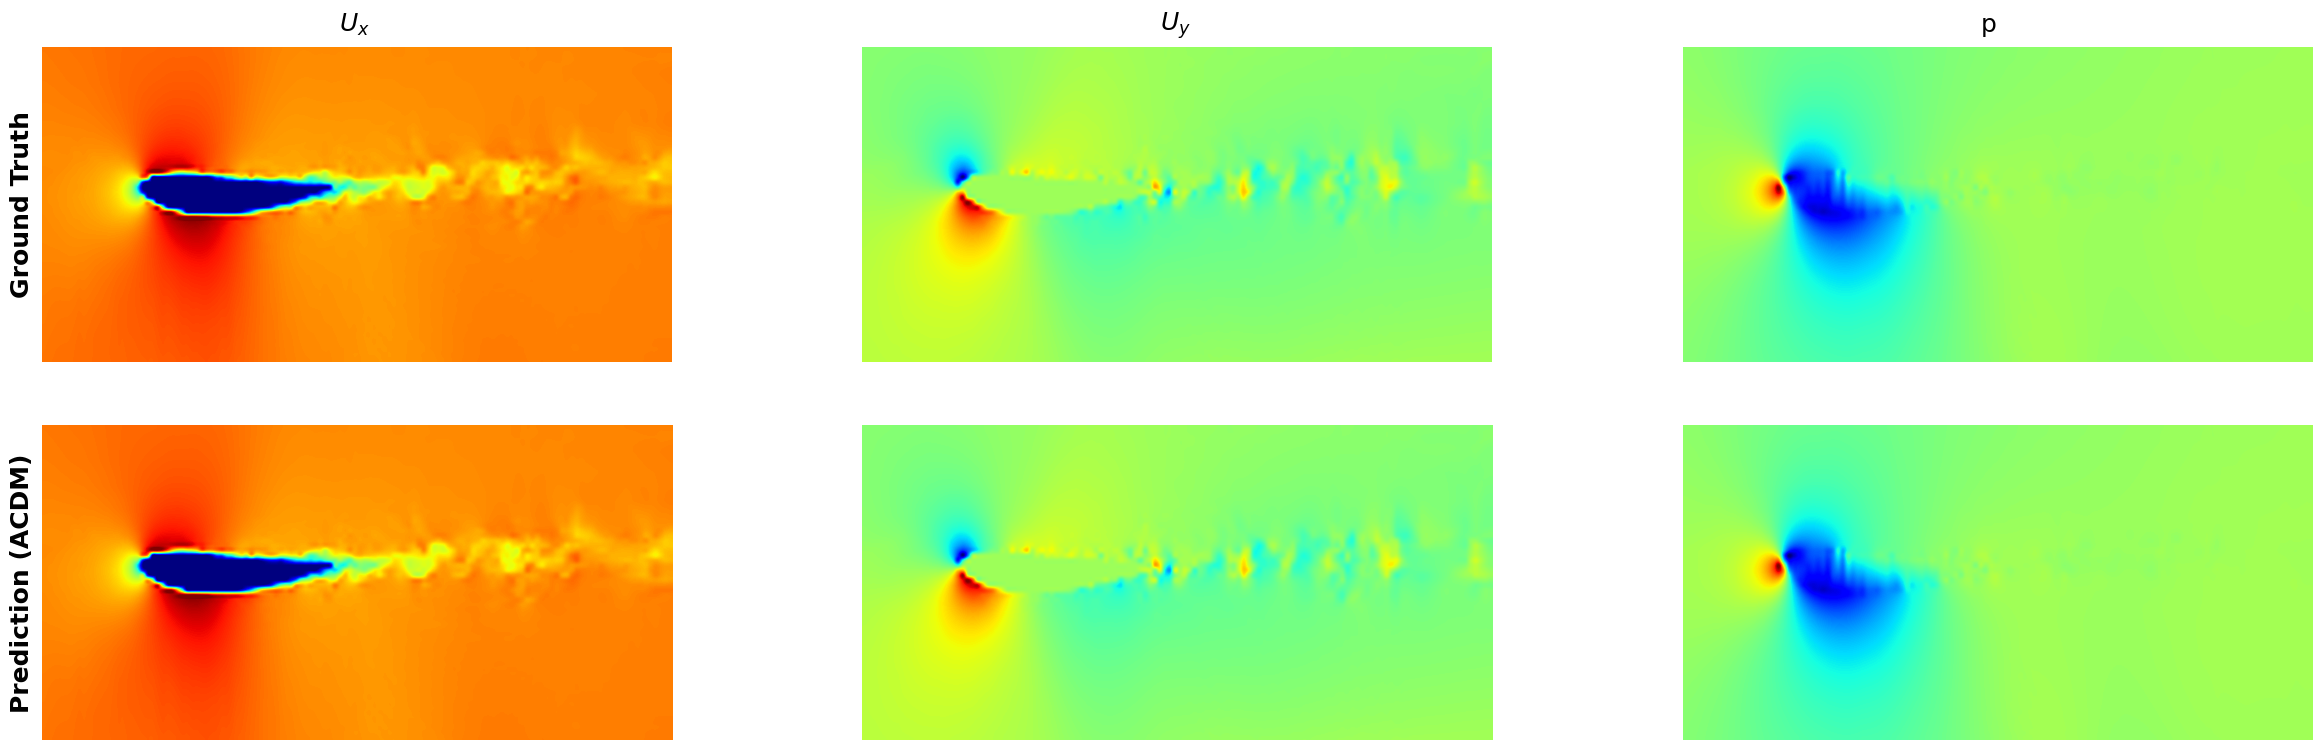

In [10]:
fig, axs = plt.subplots(2, 3, figsize=(30, 9))  # Adjust the figure size as needed
plt.rcParams['animation.embed_limit'] = 6000
def plot_frame(ground, pred, axs, frame_idx):
    cmap='jet'
    images = []
    for ax in axs.flat:
        ax.clear()
        ax.axis('off')
    i = frame_idx
    # ground_frame
    gf = ground[i, :, :, :]
    # ug, vg, pg, _ = gf.clip(-12, 8)
    ug, vg, pg, _ = gf
    
    images.append(axs[0][0].imshow(ug.T, interpolation="catrom", cmap=cmap))
    images.append(axs[0][1].imshow(vg.T, interpolation="catrom", cmap=cmap))
    images.append(axs[0][2].imshow(pg.T, interpolation="catrom", cmap=cmap))
    axs[0][0].text(-0.05, 0.5, 'Ground Truth', va='center', rotation='vertical',
                   transform=axs[0][0].transAxes, fontsize=18, fontweight="bold")
    axs[0][0].text(60, -5, '$U_{x}$', va='center', fontsize=18)
    axs[0][1].text(60, -5, '$U_{y}$', va='center', fontsize=18)
    axs[0][2].text(60, -5, 'p', va='center', fontsize=18)
    # prediction frame
    pf = pred[i, :, :, :]
    # up, vp, pp, _ = pf.clip(-12, 8)
    up, vp, pp, _ = pf
    images.append(axs[1][0].imshow(up.T, interpolation="catrom", cmap=cmap))
    images.append(axs[1][1].imshow(vp.T, interpolation="catrom", cmap=cmap))
    images.append(axs[1][2].imshow(pp.T, interpolation="catrom", cmap=cmap))
    axs[1][0].text(-0.05, 0.5, 'Prediction (ACDM)', va='center', rotation='vertical',
                   transform=axs[1][0].transAxes, fontsize=18, fontweight="bold")
    return fig

update = partial(plot_frame, ground, pred, axs)

plot_frame(ground, pred, axs, 0)
anim = FuncAnimation(fig, update, frames=200, interval=30)
HTML(anim.to_html5_video())
